## Import libraries

In [35]:
import warnings
warnings.filterwarnings("ignore")

In [36]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
import tensorflow as tf
from tensorflow.keras import layers
from tabulate import tabulate
from pydantic import BaseModel
from typing import Dict, List
import time

I0000 00:00:1773185401.115498  117494 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1773185403.010713  117494 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1773185408.545848  117494 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [37]:

class ModelResult(BaseModel):
    model_name: str
    training_time_s: float
    inference_time_ms: float       # per-sample inference latency
    accuracy: float
    precision: float               # weighted
    recall: float                  # weighted
    f1_score: float                # weighted
    confusion_matrix: List[List[int]]
    per_class_metrics: Dict[str, Dict[str, float]]  # class label -> {precision, recall, f1-score, support}

    def to_summary_dict(self) -> dict:
        """Flat dict suitable for a summary comparison table row."""
        return {
            'Model':                   self.model_name,
            'Accuracy (%)':            round(self.accuracy  * 100, 3),
            'Precision (%)':           round(self.precision * 100, 3),
            'Recall (%)':              round(self.recall    * 100, 3),
            'F1-Score (%)':            round(self.f1_score  * 100, 3),
            'Train Time (s)':          round(self.training_time_s,  3),
            'Infer. Time (ms/sample)': round(self.inference_time_ms, 4),
        }


### Load data

In [38]:
# Read the dataset
df = pd.read_csv('CICEVSE2024_12classes_kmeans_rule_sampled1000.csv')


In [39]:
df

,expiration_id,src_ip,src_mac,src_oui,src_port,dst_ip,dst_mac,dst_oui,dst_port,protocol,...,application_name,application_category_name,application_is_guessed,application_confidence,requested_server_name,client_fingerprint,server_fingerprint,user_agent,content_type,Label
0,0.0,0.396825,0.500000,0.714286,0.135668,0.400000,0.764706,0.777778,0.000336,0.020408,...,0.830769,0.705882,1.0,0.166667,1.0,1.0,1.0,1.0,1.0,5
1,0.0,0.476190,0.500000,0.714286,0.347005,0.453333,0.176471,0.111111,0.001221,0.020408,...,0.230769,1.000000,1.0,0.166667,1.0,1.0,1.0,1.0,1.0,5
2,0.0,0.317460,0.833333,0.857143,0.703655,0.346667,0.705882,0.777778,0.008286,0.020408,...,0.938462,0.823529,0.0,0.000000,1.0,1.0,1.0,1.0,1.0,1
3,0.0,0.539683,0.500000,0.714286,0.942000,0.400000,0.705882,0.777778,0.000336,0.020408,...,0.830769,0.705882,1.0,0.166667,1.0,1.0,1.0,1.0,1.0,10
4,0.0,0.396825,0.500000,0.714286,0.152590,0.400000,0.764706,0.777778,0.000336,0.020408,...,0.830769,0.705882,1.0,0.166667,1.0,1.0,1.0,1.0,1.0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35936,0.0,0.396825,0.500000,0.714286,0.660441,0.400000,0.764706,0.777778,0.000336,0.020408,...,0.830769,0.705882,1.0,0.166667,1.0,1.0,1.0,1.0,1.0,5
35937,0.0,0.539683,0.500000,0.714286,0.929381,0.400000,0.764706,0.777778,0.145495,0.020408,...,0.938462,0.823529,0.0,0.000000,1.0,1.0,1.0,1.0,1.0,2
35938,0.0,0.317460,0.833333,0.857143,0.690272,0.346667,0.705882,0.777778,0.045853,0.020408,...,0.938462,0.823529,0.0,0.000000,1.0,1.0,1.0,1.0,1.0,3
35939,0.0,0.539683,0.500000,0.714286,0.799344,0.400000,0.705882,0.777778,0.084077,0.020408,...,0.938462,0.823529,0.0,0.000000,1.0,1.0,1.0,1.0,1.0,1


In [40]:
# print the class distribution of the last column
df['Label'].value_counts()

Label
7     7696
3     5807
1     4739
8     3690
2     3421
5     3110
11    2787
10    1898
9     1577
6     1044
4       90
0       82
Name: count, dtype: int64

| Name                                                   | Original Number of Samples | Reduced Subset | Label |
|--------------------------------------------------------|----------------------------|----------------|-------|
| Class 2 DoS: TCP floods                                | 721044                     | 7696           | 7     |
| Class 1 Discovery: Stealth SYN scanning                | 530946                     | 5807           | 3     |
| Class 1 Discovery: Port scanning                       | 426659                     | 4739           | 1     |
| Class 1 Discovery: Service detection                   | 292856                     | 3690           | 8     |
| Class 2 DoS: Identity rotation and rotation flood      | 262185                     | 3421           | 2    |
| Class 3 Reconnaissance: Vulnerability scan             | 231367                     | 3110           | 5     |
| Class 3 Reconnaissance: OS fingerprinting              | 140273                     | 2787           | 11    |
| Class 3 Reconnaissance: Aggressive scan                | 102522                     | 1898           | 10    |
| Class 2 DoS: UDP flood                                 | 32475                      | 1577           | 9     |
| Class 2 DoS: Slow request starvation                   | 4201                       | 1044           | 6     |
| Class 2 DoS: ICMP flood or fragmentation               | 90                         | 90             | 4     |
| Class 0 Normal                                         | 82                         | 82             | 0     |

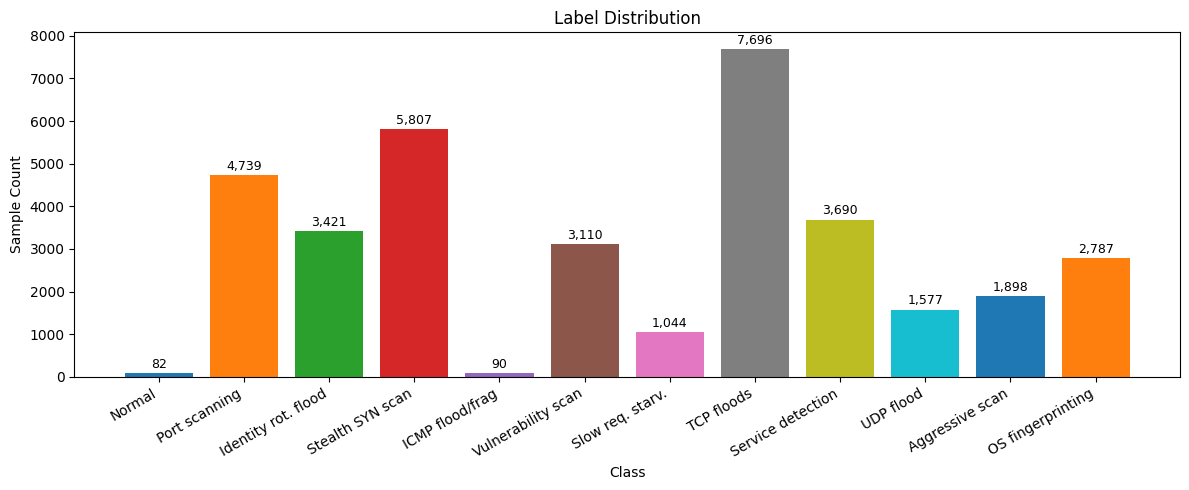

In [41]:
# Bar plot of label value counts with class names
label_names = {
    0: 'Normal',
    1: 'Port scanning',
    2: 'Identity rot. flood',
    3: 'Stealth SYN scan',
    4: 'ICMP flood/frag',
    5: 'Vulnerability scan',
    6: 'Slow req. starv.',
    7: 'TCP floods',
    8: 'Service detection',
    9: 'UDP flood',
    10: 'Aggressive scan',
    11: 'OS fingerprinting',
}

counts = df['Label'].value_counts().sort_index()
labels = [label_names[i] for i in counts.index]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(labels, counts.values, color=sns.color_palette('tab10', len(counts)))
ax.set_xlabel('Class')
ax.set_ylabel('Sample Count')
ax.set_title('Label Distribution')
ax.set_xticklabels(labels, rotation=30, ha='right')

for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
            f'{val:,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


### Data pre-processing

In [42]:
# Encode the dataset
labelencoder = LabelEncoder()
df.iloc[:, -1] = labelencoder.fit_transform(df.iloc[:, -1])


In [43]:
# min-max normalization
for column in df.columns[:-1]: # excluding the last column
    df[column] = (df[column] - df[column].min()) / (df[column].max() - df[column].min())
    

In [44]:
# address empty values
if df.isnull().values.any() or np.isinf(df).values.any(): # if there is any empty or infinite values
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.fillna(0, inplace = True)

In [45]:
X = df.drop(['Label'],axis=1)
y = df.iloc[:, -1]

# Split the dataset into training and testing sets (80%, 20%)
X_train, X_test, y_train, y_test = train_test_split(X,y, train_size = 0.8, test_size = 0.2, random_state = 0,stratify = y)


### Reference Models from Literature

| Paper | Link | Models |
|-------|------|--------|
| Tree-based Intelligent Intrusion Detection System in Internet of Vehicles | [arXiv:1910.08635](https://arxiv.org/pdf/1910.08635) | Random Forest, Decision Tree, Extra Tree, XGBoost |
| MTH-IDS: A Multitiered Hybrid Intrusion Detection System for Internet of Vehicles | [IEEE Xplore](https://ieeexplore-ieee-org.uproxy.library.dc-uoit.ca/document/9443234) | Multi-SVM, KNN |
|A Transfer Learning and Optimized CNN Based Intrusion Detection System for Internet of Vehicles| [IEEE Xplore](https://ieeexplore-ieee-org.uproxy.library.dc-uoit.ca/document/9838780) | VGG16, VGG19|
|Deep Learning Approach for Intelligent Intrusion Detection System| [IEEE Xplore](https://ieeexplore.ieee.org/abstract/document/8681044)| DNN, LR|


In [46]:
def train_xgboost(
    X_train, X_test, y_train, y_test,
    model_name: str = "XGBoost",
    **xgb_kwargs,
) -> ModelResult:
    """Train an XGBoost classifier and return structured evaluation results."""

    model = xgb.XGBClassifier(random_state=42, **xgb_kwargs)

    start = time.time()
    model.fit(X_train, y_train)
    training_time = time.time() - start

    start = time.time()
    y_pred = model.predict(X_test)
    inference_time = (time.time() - start) / len(X_test) * 1000

    accuracy  = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')

    conf_matrix  = confusion_matrix(y_test, y_pred)
    report_dict  = classification_report(y_test, y_pred, output_dict=True)

    # Keep only per-class rows (exclude aggregate rows)
    per_class = {
        k: {m: float(v) for m, v in metrics.items()}
        for k, metrics in report_dict.items()
        if isinstance(metrics, dict) and k not in ('macro avg', 'weighted avg')
    }

    return ModelResult(
        model_name=model_name,
        training_time_s=training_time,
        inference_time_ms=inference_time,
        accuracy=float(accuracy),
        precision=float(precision),
        recall=float(recall),
        f1_score=float(f1),
        confusion_matrix=conf_matrix.tolist(),
        per_class_metrics=per_class,
    )


# --- Train default XGBoost ---
xgb_result = train_xgboost(X_train, X_test, y_train, y_test, model_name="XGBoost (default)")
print(f"Done — {xgb_result.model_name}  |  Accuracy: {xgb_result.accuracy*100:.3f}%")


Done — XGBoost (default)  |  Accuracy: 99.847%


In [47]:
def train_random_forest(
    X_train, X_test, y_train, y_test,
    model_name: str = "Random Forest",
    **kwargs,
) -> ModelResult:
    """Train a Random Forest classifier."""
    model = RandomForestClassifier(random_state=42, **kwargs)

    start = time.time()
    model.fit(X_train, y_train)
    training_time = time.time() - start

    start = time.time()
    y_pred = model.predict(X_test)
    inference_time = (time.time() - start) / len(X_test) * 1000

    accuracy = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')
    conf_matrix = confusion_matrix(y_test, y_pred)
    report_dict = classification_report(y_test, y_pred, output_dict=True)
    per_class = {
        k: {m: float(v) for m, v in metrics.items()}
        for k, metrics in report_dict.items()
        if isinstance(metrics, dict) and k not in ('macro avg', 'weighted avg')
    }

    return ModelResult(
        model_name=model_name,
        training_time_s=training_time,
        inference_time_ms=inference_time,
        accuracy=float(accuracy),
        precision=float(precision),
        recall=float(recall),
        f1_score=float(f1),
        confusion_matrix=conf_matrix.tolist(),
        per_class_metrics=per_class,
    )


rf_result = train_random_forest(X_train, X_test, y_train, y_test)
print(f"Done — {rf_result.model_name}  |  Accuracy: {rf_result.accuracy*100:.3f}%")


Done — Random Forest  |  Accuracy: 99.917%


In [48]:
def train_decision_tree(
    X_train, X_test, y_train, y_test,
    model_name: str = "Decision Tree",
    **kwargs,
) -> ModelResult:
    """Train a CART Decision Tree classifier."""
    model = DecisionTreeClassifier(random_state=42, **kwargs)

    start = time.time()
    model.fit(X_train, y_train)
    training_time = time.time() - start

    start = time.time()
    y_pred = model.predict(X_test)
    inference_time = (time.time() - start) / len(X_test) * 1000

    accuracy = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')
    conf_matrix = confusion_matrix(y_test, y_pred)
    report_dict = classification_report(y_test, y_pred, output_dict=True)
    per_class = {
        k: {m: float(v) for m, v in metrics.items()}
        for k, metrics in report_dict.items()
        if isinstance(metrics, dict) and k not in ('macro avg', 'weighted avg')
    }

    return ModelResult(
        model_name=model_name,
        training_time_s=training_time,
        inference_time_ms=inference_time,
        accuracy=float(accuracy),
        precision=float(precision),
        recall=float(recall),
        f1_score=float(f1),
        confusion_matrix=conf_matrix.tolist(),
        per_class_metrics=per_class,
    )


dt_result = train_decision_tree(X_train, X_test, y_train, y_test)
print(f"Done — {dt_result.model_name}  |  Accuracy: {dt_result.accuracy*100:.3f}%")


Done — Decision Tree  |  Accuracy: 99.958%


In [49]:
def train_extra_trees(
    X_train, X_test, y_train, y_test,
    model_name: str = "Extra Trees",
    **kwargs,
) -> ModelResult:
    """Train an Extra Trees (Extremely Randomized Trees) classifier."""
    model = ExtraTreesClassifier(random_state=42, **kwargs)

    start = time.time()
    model.fit(X_train, y_train)
    training_time = time.time() - start

    start = time.time()
    y_pred = model.predict(X_test)
    inference_time = (time.time() - start) / len(X_test) * 1000

    accuracy = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')
    conf_matrix = confusion_matrix(y_test, y_pred)
    report_dict = classification_report(y_test, y_pred, output_dict=True)
    per_class = {
        k: {m: float(v) for m, v in metrics.items()}
        for k, metrics in report_dict.items()
        if isinstance(metrics, dict) and k not in ('macro avg', 'weighted avg')
    }

    return ModelResult(
        model_name=model_name,
        training_time_s=training_time,
        inference_time_ms=inference_time,
        accuracy=float(accuracy),
        precision=float(precision),
        recall=float(recall),
        f1_score=float(f1),
        confusion_matrix=conf_matrix.tolist(),
        per_class_metrics=per_class,
    )


et_result = train_extra_trees(X_train, X_test, y_train, y_test)
print(f"Done — {et_result.model_name}  |  Accuracy: {et_result.accuracy*100:.3f}%")


Done — Extra Trees  |  Accuracy: 99.819%


In [ ]:
def train_svm(
    X_train, X_test, y_train, y_test,
    model_name: str = "Multi-SVM",
    **kwargs,
) -> ModelResult:
    """
    Train a multi-class SVM (OvO by default via SVC) with RBF kernel.
    """
    print(f"Training {model_name} — this may take several minutes on large data...")
    model = SVC(random_state=42, **kwargs)

    start = time.time()
    model.fit(X_train, y_train)
    training_time = time.time() - start

    start = time.time()
    y_pred = model.predict(X_test)
    inference_time = (time.time() - start) / len(X_test) * 1000

    accuracy = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')
    conf_matrix = confusion_matrix(y_test, y_pred)
    report_dict = classification_report(y_test, y_pred, output_dict=True)
    per_class = {
        k: {m: float(v) for m, v in metrics.items()}
        for k, metrics in report_dict.items()
        if isinstance(metrics, dict) and k not in ('macro avg', 'weighted avg')
    }

    return ModelResult(
        model_name=model_name,
        training_time_s=training_time,
        inference_time_ms=inference_time,
        accuracy=float(accuracy),
        precision=float(precision),
        recall=float(recall),
        f1_score=float(f1),
        confusion_matrix=conf_matrix.tolist(),
        per_class_metrics=per_class,
    )


svm_result = train_svm(X_train, X_test, y_train, y_test)
print(f"Done — {svm_result.model_name}  |  Accuracy: {svm_result.accuracy*100:.3f}%")


Training Multi-SVM — this may take several minutes on large data...
Done — Multi-SVM  |  Accuracy: 59.438%


In [51]:
def train_knn(
    X_train, X_test, y_train, y_test,
    model_name: str = "KNN",
    **kwargs,
) -> ModelResult:
    """Train a K-Nearest Neighbours classifier."""
    model = KNeighborsClassifier(**kwargs)  # KNN has no random_state

    start = time.time()
    model.fit(X_train, y_train)
    training_time = time.time() - start

    start = time.time()
    y_pred = model.predict(X_test)
    inference_time = (time.time() - start) / len(X_test) * 1000

    accuracy = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')
    conf_matrix = confusion_matrix(y_test, y_pred)
    report_dict = classification_report(y_test, y_pred, output_dict=True)
    per_class = {
        k: {m: float(v) for m, v in metrics.items()}
        for k, metrics in report_dict.items()
        if isinstance(metrics, dict) and k not in ('macro avg', 'weighted avg')
    }

    return ModelResult(
        model_name=model_name,
        training_time_s=training_time,
        inference_time_ms=inference_time,
        accuracy=float(accuracy),
        precision=float(precision),
        recall=float(recall),
        f1_score=float(f1),
        confusion_matrix=conf_matrix.tolist(),
        per_class_metrics=per_class,
    )


knn_result = train_knn(X_train, X_test, y_train, y_test)
print(f"Done — {knn_result.model_name}  |  Accuracy: {knn_result.accuracy*100:.3f}%")


Done — KNN  |  Accuracy: 60.885%


In [52]:
def train_logistic_regression(
    X_train, X_test, y_train, y_test,
    model_name: str = "Logistic Regression",
    **kwargs,
) -> ModelResult:
    """Train a multinomial Logistic Regression classifier."""
    model = LogisticRegression(random_state=42, max_iter=1000, **kwargs)

    start = time.time()
    model.fit(X_train, y_train)
    training_time = time.time() - start

    start = time.time()
    y_pred = model.predict(X_test)
    inference_time = (time.time() - start) / len(X_test) * 1000

    accuracy = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')
    conf_matrix = confusion_matrix(y_test, y_pred)
    report_dict = classification_report(y_test, y_pred, output_dict=True)
    per_class = {
        k: {m: float(v) for m, v in metrics.items()}
        for k, metrics in report_dict.items()
        if isinstance(metrics, dict) and k not in ('macro avg', 'weighted avg')
    }

    return ModelResult(
        model_name=model_name,
        training_time_s=training_time,
        inference_time_ms=inference_time,
        accuracy=float(accuracy),
        precision=float(precision),
        recall=float(recall),
        f1_score=float(f1),
        confusion_matrix=conf_matrix.tolist(),
        per_class_metrics=per_class,
    )


lr_result = train_logistic_regression(X_train, X_test, y_train, y_test)
print(f"Done — {lr_result.model_name}  |  Accuracy: {lr_result.accuracy*100:.3f}%")


Done — Logistic Regression  |  Accuracy: 59.605%


In [53]:
def train_dnn(
    X_train, X_test, y_train, y_test,
    model_name: str = "DNN",
    epochs: int = 50,
    batch_size: int = 256,
) -> ModelResult:
    """
    Deep Neural Network per the paper architecture:
    FC(1024)→BN→Drop → FC(768)→BN→Drop → FC(512)→BN→Drop
    → FC(256)→BN→Drop → FC(128)→BN→Drop → FC(n_classes, softmax)
    """
    n_classes  = len(np.unique(y_train))
    n_features = X_train.shape[1]

    inp = tf.keras.Input(shape=(n_features,))
    x = inp
    for units in [1024, 768, 512, 256, 128]:
        x = layers.Dense(units, activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(0.01)(x)
    out = layers.Dense(n_classes, activation='softmax')(x)

    model = tf.keras.Model(inp, out)
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    start = time.time()
    model.fit(X_train.values, y_train.values, epochs=epochs, batch_size=batch_size,
              validation_split=0.1, verbose=0)
    training_time = time.time() - start

    start = time.time()
    probs = model.predict(X_test.values, verbose=0)
    inference_time = (time.time() - start) / len(X_test) * 1000
    y_pred = np.argmax(probs, axis=1)

    accuracy = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')
    conf_matrix = confusion_matrix(y_test, y_pred)
    report_dict = classification_report(y_test, y_pred, output_dict=True)
    per_class = {
        k: {m: float(v) for m, v in metrics.items()}
        for k, metrics in report_dict.items()
        if isinstance(metrics, dict) and k not in ('macro avg', 'weighted avg')
    }

    return ModelResult(
        model_name=model_name,
        training_time_s=training_time,
        inference_time_ms=inference_time,
        accuracy=float(accuracy),
        precision=float(precision),
        recall=float(recall),
        f1_score=float(f1),
        confusion_matrix=conf_matrix.tolist(),
        per_class_metrics=per_class,
    )


dnn_result = train_dnn(X_train, X_test, y_train, y_test)
print(f"Done — {dnn_result.model_name}  |  Accuracy: {dnn_result.accuracy*100:.3f}%")


E0000 00:00:1773185581.351013  117494 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Done — DNN  |  Accuracy: 55.376%


In [54]:
def train_vgg16_1d(
    X_train, X_test, y_train, y_test,
    model_name: str = "VGG16 (1D-CNN)",
    epochs: int = 50,
    batch_size: int = 256,
) -> ModelResult:
    """VGG16 adapted as a 1D-CNN for tabular input (85 features → (85,1))."""
    n_classes  = len(np.unique(y_train))
    n_features = X_train.shape[1]

    X_tr = X_train.values.reshape(-1, n_features, 1)
    X_te = X_test.values.reshape(-1, n_features, 1)

    def vgg_block_1d(x, filters, n_convs):
        for _ in range(n_convs):
            x = layers.Conv1D(filters, 3, padding='same', activation='relu')(x)
        return layers.MaxPooling1D(2)(x)

    inp = tf.keras.Input(shape=(n_features, 1))
    x = vgg_block_1d(inp, 64,  2)   # block 1
    x = vgg_block_1d(x,  128, 2)   # block 2
    x = vgg_block_1d(x,  256, 3)   # block 3 (VGG16: 3 convs)
    x = vgg_block_1d(x,  512, 3)   # block 4
    x = vgg_block_1d(x,  512, 3)   # block 5
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(1024, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(1024, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    out = layers.Dense(n_classes, activation='softmax')(x)

    model = tf.keras.Model(inp, out)
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    start = time.time()
    model.fit(X_tr, y_train.values, epochs=epochs, batch_size=batch_size,
              validation_split=0.1, verbose=0)
    training_time = time.time() - start

    start = time.time()
    probs = model.predict(X_te, verbose=0)
    inference_time = (time.time() - start) / len(X_te) * 1000
    y_pred = np.argmax(probs, axis=1)

    accuracy = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')
    conf_matrix = confusion_matrix(y_test, y_pred)
    report_dict = classification_report(y_test, y_pred, output_dict=True)
    per_class = {
        k: {m: float(v) for m, v in metrics.items()}
        for k, metrics in report_dict.items()
        if isinstance(metrics, dict) and k not in ('macro avg', 'weighted avg')
    }

    return ModelResult(
        model_name=model_name,
        training_time_s=training_time,
        inference_time_ms=inference_time,
        accuracy=float(accuracy),
        precision=float(precision),
        recall=float(recall),
        f1_score=float(f1),
        confusion_matrix=conf_matrix.tolist(),
        per_class_metrics=per_class,
    )


vgg16_result = train_vgg16_1d(X_train, X_test, y_train, y_test)
print(f"Done — {vgg16_result.model_name}  |  Accuracy: {vgg16_result.accuracy*100:.3f}%")


KeyboardInterrupt: 

In [ ]:
def train_vgg19_1d(
    X_train, X_test, y_train, y_test,
    model_name: str = "VGG19 (1D-CNN)",
    epochs: int = 50,
    batch_size: int = 256,
) -> ModelResult:
    """VGG19 adapted as a 1D-CNN for tabular input. Blocks 3/4/5 use 4 Conv1D layers (vs 3 in VGG16)."""
    n_classes  = len(np.unique(y_train))
    n_features = X_train.shape[1]

    X_tr = X_train.values.reshape(-1, n_features, 1)
    X_te = X_test.values.reshape(-1, n_features, 1)

    def vgg_block_1d(x, filters, n_convs):
        for _ in range(n_convs):
            x = layers.Conv1D(filters, 3, padding='same', activation='relu')(x)
        return layers.MaxPooling1D(2)(x)

    inp = tf.keras.Input(shape=(n_features, 1))
    x = vgg_block_1d(inp, 64,  2)   # block 1
    x = vgg_block_1d(x,  128, 2)   # block 2
    x = vgg_block_1d(x,  256, 4)   # block 3 — VGG19: 4 convs
    x = vgg_block_1d(x,  512, 4)   # block 4
    x = vgg_block_1d(x,  512, 4)   # block 5
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(1024, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(1024, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    out = layers.Dense(n_classes, activation='softmax')(x)

    model = tf.keras.Model(inp, out)
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    start = time.time()
    model.fit(X_tr, y_train.values, epochs=epochs, batch_size=batch_size,
              validation_split=0.1, verbose=0)
    training_time = time.time() - start

    start = time.time()
    probs = model.predict(X_te, verbose=0)
    inference_time = (time.time() - start) / len(X_te) * 1000
    y_pred = np.argmax(probs, axis=1)

    accuracy = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')
    conf_matrix = confusion_matrix(y_test, y_pred)
    report_dict = classification_report(y_test, y_pred, output_dict=True)
    per_class = {
        k: {m: float(v) for m, v in metrics.items()}
        for k, metrics in report_dict.items()
        if isinstance(metrics, dict) and k not in ('macro avg', 'weighted avg')
    }

    return ModelResult(
        model_name=model_name,
        training_time_s=training_time,
        inference_time_ms=inference_time,
        accuracy=float(accuracy),
        precision=float(precision),
        recall=float(recall),
        f1_score=float(f1),
        confusion_matrix=conf_matrix.tolist(),
        per_class_metrics=per_class,
    )


vgg19_result = train_vgg19_1d(X_train, X_test, y_train, y_test)
print(f"Done — {vgg19_result.model_name}  |  Accuracy: {vgg19_result.accuracy*100:.3f}%")


In [ ]:
# Accumulate all ModelResult objects — add/remove entries here as needed
results: List[ModelResult] = [
    xgb_result,
    rf_result,
    dt_result,
    et_result,
    svm_result,
    knn_result,
    lr_result,
    dnn_result,
    vgg16_result,
    vgg19_result,
]

summary_df = pd.DataFrame([r.to_summary_dict() for r in results]).set_index('Model')
display(summary_df.style
    .format(precision=3)
    .highlight_max(subset=['Accuracy (%)', 'Precision (%)', 'Recall (%)', 'F1-Score (%)'], color='lightgreen')
    .highlight_min(subset=['Train Time (s)', 'Infer. Time (ms/sample)'], color='lightblue')
    .set_caption("Model Comparison Summary")
)
